# Supply Chain Dataset: Exploratory Data Analysis


### 0. Importing Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the Dataset


In [41]:
df = pd.read_csv(r"C:\Users\DIL\OneDrive\Documents\Supply_Chain-Analysis\Python-EDA\dataset.csv",encoding='latin1')
print(f"Dataset loaded")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Dataset loaded
Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 2. Understand the Dataset

Inspect the shape, field names, data types, and sample records from both ends of the file. This helps distinguish numeric measures, categorical fields, dates, and identifiers before analysis.

In [5]:
print("DataFrame shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nColumn data types:")
display(df.dtypes.rename("data_type").to_frame())
print("\nFirst five rows:")
display(df.head())
print("\nLast five rows:")
display(df.tail())
print("\nNumeric columns:", df.select_dtypes(include="number").columns.tolist())
print("Categorical/text columns:", df.select_dtypes(include=["object", "category"]).columns.tolist())

DataFrame shape: (180519, 53)

Column names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price

,data_type
Type,object
Days for shipping (real),int64
Days for shipment (scheduled),int64
Benefit per order,float64
Sales per customer,float64
Delivery Status,object
Late_delivery_risk,int64
Category Id,int64
Category Name,object
Customer City,object



First five rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class



Last five rows:


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.0,7,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.0,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.0,7,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.0,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.0,7,Fan Shop,41.629959,-72.967155,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.0,0.02,65129,399.980011,0.36,1,399.980011,391.980011,141.110001,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.0,7,Fan Shop,18.213350,-66.370575,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.0,0.03,65126,399.980011,0.48,1,399.980011,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.0,7,Fan Shop,18.290380,-66.370613,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.0,0.04,65113,399.980011,0.44,1,399.980011,383.980011,168.949997,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class



Numeric columns: ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id', 'Latitude', 'Longitude', 'Order Customer Id', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Price', 'Product Status']
Categorical/text columns: ['Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Region', 'Order State', 'Order Status', 'Product Ima

## 3. Missing Values and Duplicates

Count missing values by field, including blank-only strings, then check exact duplicate rows and the row-level order-item key. Repeated order IDs are expected because an order can contain multiple items.

In [6]:
# Treat whitespace-only text as missing without changing the source DataFrame.
missing_mask = df.isna().copy()
for column in df.select_dtypes(include=["object", "string"]).columns:
    missing_mask[column] |= df[column].astype("string").str.strip().eq("").fillna(False)

missing_summary = pd.DataFrame({
    "missing_count": missing_mask.sum(),
    "missing_percent": (missing_mask.mean() * 100).round(2),
}).sort_values("missing_count", ascending=False)
print("Missing values by column:")
display(missing_summary)

print(f"Exact duplicate rows: {df.duplicated().sum():,}")
if "Order Item Id" in df.columns:
    repeated_item_ids = df["Order Item Id"].duplicated(keep=False)
    print(f"Rows with a repeated Order Item Id: {repeated_item_ids.sum():,}")

# Parse dates only for validation; retain the original string columns.
for date_column in ["order date (DateOrders)", "shipping date (DateOrders)"]:
    if date_column in df.columns:
        parsed_dates = pd.to_datetime(df[date_column], errors="coerce")
        invalid_dates = df[date_column].notna() & parsed_dates.isna()
        print(f"{date_column}: {parsed_dates.notna().sum():,} parsed; {invalid_dates.sum():,} non-empty values failed parsing")
        if invalid_dates.any():
            display(df.loc[invalid_dates, [date_column]].head())

Missing values by column:


,missing_count,missing_percent
Product Description,180519,100.0
Order Zipcode,155679,86.24
Customer Lname,8,0.0
Customer Zipcode,3,0.0
Type,0,0.0
Order Profit Per Order,0,0.0
Order Item Cardprod Id,0,0.0
Order Item Discount,0,0.0
Order Item Discount Rate,0,0.0
Order Item Id,0,0.0


Exact duplicate rows: 0
Rows with a repeated Order Item Id: 0
order date (DateOrders): 180,519 parsed; 0 non-empty values failed parsing
shipping date (DateOrders): 180,519 parsed; 0 non-empty values failed parsing


## 4. Potential Outliers

Use the 1.5 × IQR fences on continuous business measures (shipping days, sales, discounts, profit, and quantities). IDs, postal codes, coordinates, and binary flags are not treated as measured quantities. Outlier flags are diagnostic and do not delete records.

In [7]:
outlier_measures = [
    "Days for shipping (real)", "Days for shipment (scheduled)", "Benefit per order",
    "Sales per customer", "Order Item Discount", "Order Item Discount Rate",
    "Order Item Product Price", "Order Item Profit Ratio", "Order Item Quantity",
    "Sales", "Order Item Total", "Order Profit Per Order", "Product Price",
]
outlier_measures = [
    column for column in outlier_measures
    if column in df.columns and pd.api.types.is_numeric_dtype(df[column])
]

outlier_results = []
for column in outlier_measures:
    values = df[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    flagged = values.lt(lower_fence) | values.gt(upper_fence)
    outlier_results.append({
        "measure": column,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_fence": lower_fence,
        "upper_fence": upper_fence,
        "outlier_count": int(flagged.sum()),
        "outlier_percent": flagged.mean() * 100,
    })

outlier_summary = pd.DataFrame(outlier_results).set_index("measure")
print("Potential outlier counts using the 1.5 x IQR rule:")
display(outlier_summary.sort_values("outlier_percent", ascending=False).round(2))

Potential outlier counts using the 1.5 x IQR rule:


,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count,outlier_percent
measure,,,,,,,
Benefit per order,7.00,64.80,57.80,-79.70,151.50,18942,10.49
Order Profit Per Order,7.00,64.80,57.80,-79.70,151.50,18942,10.49
Order Item Profit Ratio,0.08,0.36,0.28,-0.34,0.78,17300,9.58
Order Item Discount,5.40,29.99,24.59,-31.48,66.87,7537,4.18
Order Item Product Price,50.00,199.99,149.99,-174.99,424.98,2048,1.13
Product Price,50.00,199.99,149.99,-174.99,424.98,2048,1.13
Sales per customer,104.38,247.40,143.02,-110.15,461.93,1943,1.08
Order Item Total,104.38,247.40,143.02,-110.15,461.93,1943,1.08
Sales,119.98,299.95,179.97,-149.98,569.91,488,0.27


## 5. Descriptive Statistics

For continuous numeric measures, calculate count, mean, median, mode, standard deviation, variance, minimum, quartiles, and maximum. The mode shown is the first mode when a measure has multiple equally frequent values.

In [8]:
statistics = pd.DataFrame(index=outlier_measures)
statistics["count"] = df[outlier_measures].count()
statistics["mean"] = df[outlier_measures].mean()
statistics["median"] = df[outlier_measures].median()
statistics["mode"] = df[outlier_measures].apply(
    lambda column: column.mode(dropna=True).iloc[0] if not column.mode(dropna=True).empty else pd.NA
)
statistics["std_dev"] = df[outlier_measures].std()
statistics["variance"] = df[outlier_measures].var()
statistics["min"] = df[outlier_measures].min()
statistics["Q1"] = df[outlier_measures].quantile(0.25)
statistics["Q2_median"] = df[outlier_measures].quantile(0.50)
statistics["Q3"] = df[outlier_measures].quantile(0.75)
statistics["max"] = df[outlier_measures].max()
print("Descriptive statistics for numeric business measures:")
display(statistics.round(3))

Descriptive statistics for numeric business measures:


,count,mean,median,mode,std_dev,variance,min,Q1,Q2_median,Q3,max
Days for shipping (real),180519,3.498,3.00,2.00,1.624,2.636,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519,2.932,4.00,4.00,1.374,1.889,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519,21.975,31.52,0.00,104.434,10906.361,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519,183.108,163.99,122.84,120.044,14410.483,7.49,104.38,163.99,247.40,1939.99
Order Item Discount,180519,20.665,14.00,0.00,21.801,475.279,0.00,5.40,14.00,29.99,500.00
Order Item Discount Rate,180519,0.102,0.10,0.03,0.070,0.005,0.00,0.04,0.10,0.16,0.25
Order Item Product Price,180519,141.233,59.99,59.99,139.732,19525.169,9.99,50.00,59.99,199.99,1999.99
Order Item Profit Ratio,180519,0.121,0.27,0.48,0.467,0.218,-2.75,0.08,0.27,0.36,0.50
Order Item Quantity,180519,2.128,1.00,1.00,1.453,2.113,1.00,1.00,1.00,3.00,5.00
Sales,180519,203.772,199.92,129.99,132.273,17496.167,9.99,119.98,199.92,299.95,1999.99


## 6. Univariate Analysis

Study one variable at a time: histograms and boxplots for selected numeric measures, and frequency tables for operational categories. Personal names, contact fields, addresses, and row identifiers are intentionally excluded.

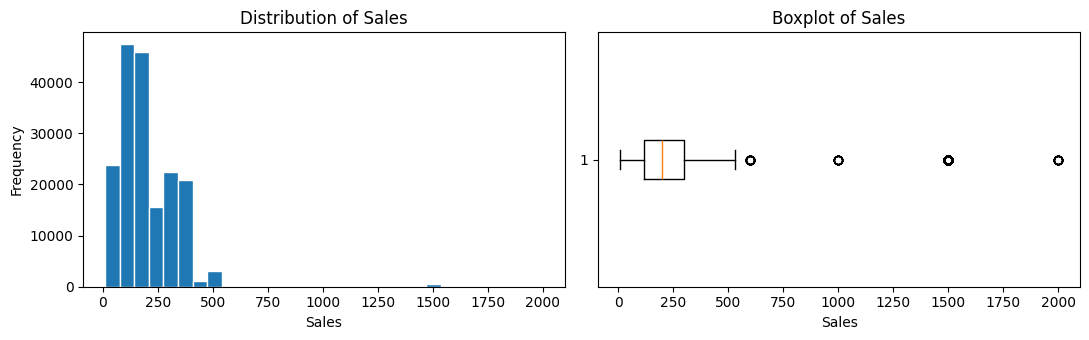

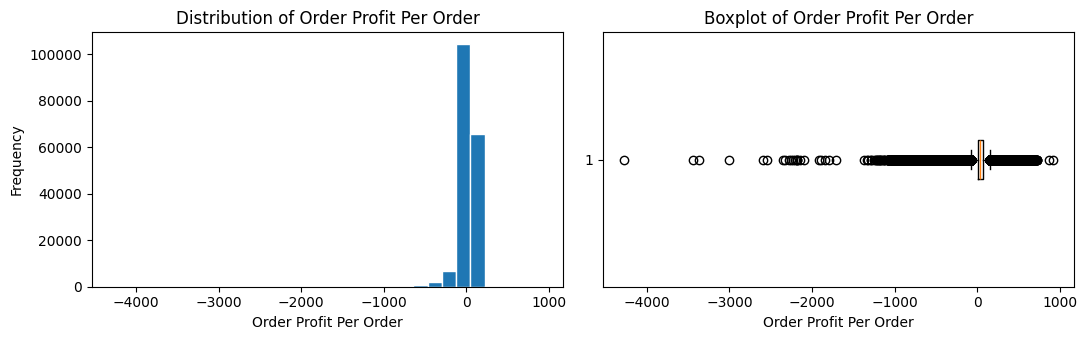

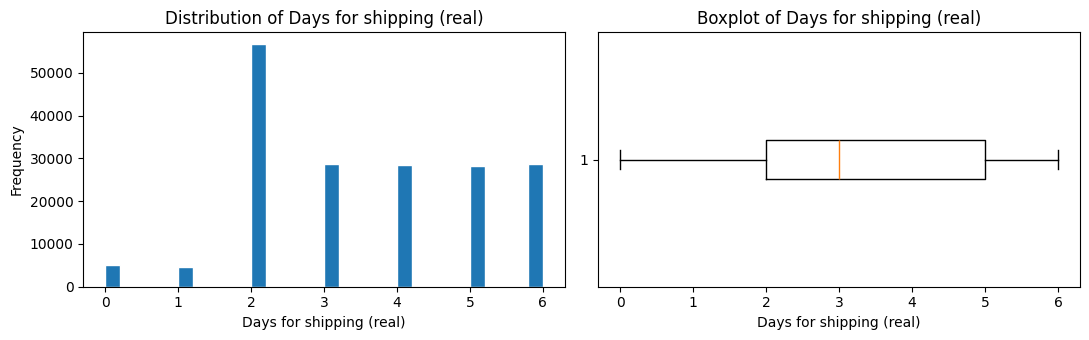

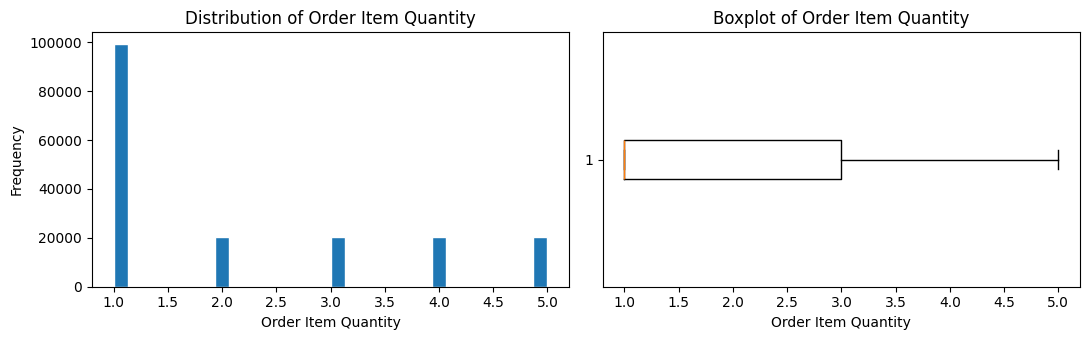


Type frequency (top 10):


,count,percent
Type,,
DEBIT,69295,38.39
TRANSFER,49883,27.63
PAYMENT,41725,23.11
CASH,19616,10.87



Delivery Status frequency (top 10):


,count,percent
Delivery Status,,
Late delivery,98977,54.83
Advance shipping,41592,23.04
Shipping on time,32196,17.84
Shipping canceled,7754,4.30



Late_delivery_risk frequency (top 10):


...

,count,percent
Order Region,,
Central America,28341,15.70
Western Europe,27109,15.02
South America,14935,8.27
Oceania,10148,5.62
Northern Europe,9792,5.42
Southeast Asia,9539,5.28
Southern Europe,9431,5.22
Caribbean,8318,4.61
West of USA,7993,4.43



Order Status frequency (top 10):


,count,percent
Order Status,,
COMPLETE,59491,32.96
PENDING_PAYMENT,39832,22.07
PROCESSING,21902,12.13
PENDING,20227,11.20
CLOSED,19616,10.87
ON_HOLD,9804,5.43
SUSPECTED_FRAUD,4062,2.25
CANCELED,3692,2.05
PAYMENT_REVIEW,1893,1.05



Shipping Mode frequency (top 10):


,count,percent
Shipping Mode,,
Standard Class,107752,59.69
Second Class,35216,19.51
First Class,27814,15.41
Same Day,9737,5.39


In [9]:
plot_measures = [
    column for column in ["Sales", "Order Profit Per Order", "Days for shipping (real)", "Order Item Quantity"]
    if column in outlier_measures
]
for column in plot_measures:
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].hist(df[column].dropna(), bins=30, edgecolor="white")
    axes[0].set_title(f"Distribution of {column}")
    axes[0].set_xlabel(column)
    axes[0].set_ylabel("Frequency")
    axes[1].boxplot(df[column].dropna(), vert=False, showfliers=True)
    axes[1].set_title(f"Boxplot of {column}")
    axes[1].set_xlabel(column)
    fig.tight_layout()
    plt.show()

# Limit category frequency tables to business fields with interpretable values.
category_columns = [
    "Type", "Delivery Status", "Late_delivery_risk", "Category Name", "Customer Segment",
    "Department Name", "Market", "Order Region", "Order Status", "Shipping Mode",
]
category_columns = [column for column in category_columns if column in df.columns]
for column in category_columns:
    counts = df[column].value_counts(dropna=False).head(10)
    percentages = df[column].value_counts(normalize=True, dropna=False).head(10).mul(100)
    print(f"\n{column} frequency (top 10):")
    display(pd.DataFrame({"count": counts, "percent": percentages.round(2)}))

## 7. Bivariate Analysis

Compare pairs of variables to look for relationships: numeric correlations, sales/profit by market, delivery status by shipping mode, and late-delivery risk by shipping mode. These associations are descriptive and do not establish causation.

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
Days for shipping (real),1.00,0.52,-0.01,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.01,0.00
Days for shipment (scheduled),0.52,1.00,-0.00,0.01,0.00,0.00,0.01,-0.00,-0.00,0.01,0.01,-0.00,0.01
Benefit per order,-0.01,-0.00,1.00,0.13,0.06,-0.02,0.10,0.82,0.02,0.13,0.13,1.00,0.10
Sales per customer,0.00,0.01,0.13,1.00,0.50,-0.12,0.78,-0.00,0.11,0.99,1.00,0.13,0.78
Order Item Discount,0.00,0.00,0.06,0.50,1.00,0.66,0.49,-0.00,0.07,0.62,0.50,0.06,0.49
Order Item Discount Rate,0.00,0.00,-0.02,-0.12,0.66,1.00,0.00,-0.00,-0.00,0.00,-0.12,-0.02,0.00
Order Item Product Price,0.00,0.01,0.10,0.78,0.49,0.00,1.00,-0.00,-0.48,0.79,0.78,0.10,1.00
Order Item Profit Ratio,-0.00,-0.00,0.82,-0.00,-0.00,-0.00,-0.00,1.00,0.00,-0.00,-0.00,0.82,-0.00
Order Item Quantity,-0.00,-0.00,0.02,0.11,0.07,-0.00,-0.48,0.00,1.00,0.11,0.11,0.02,-0.48
Sales,0.00,0.01,0.13,0.99,0.62,0.00,0.79,-0.00,0.11,1.00,0.99,0.13,0.79


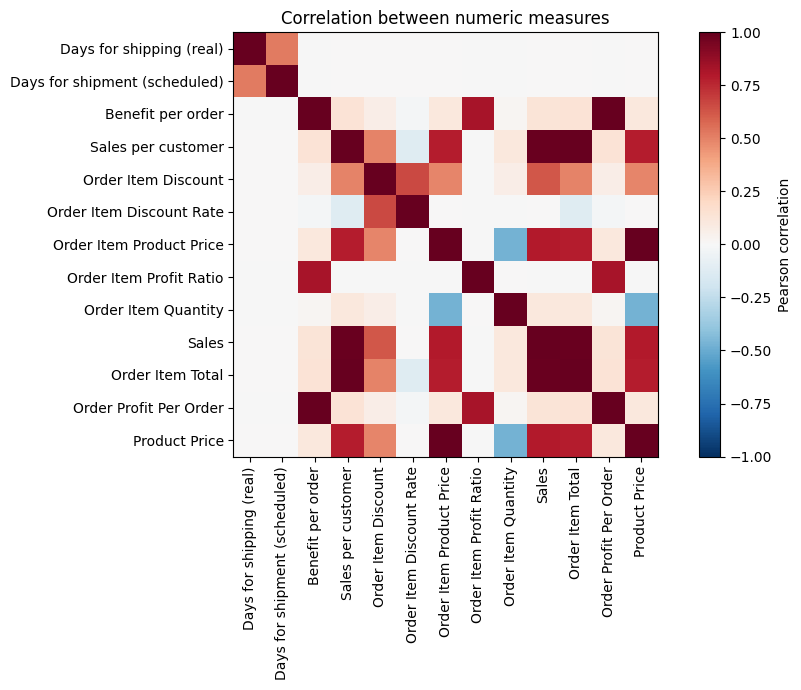

Sales and profit summary by market:


,record_count,mean_sales,median_sales,total_sales,mean_profit_per_order
Market,,,,,
Europe,50252,216.36,199.95,10872396.80,23.27
LATAM,51594,199.20,199.92,10277612.84,21.77
Pacific Asia,41260,200.53,199.92,8273743.74,20.79
USCA,25799,196.38,179.97,5066528.71,21.87
Africa,11614,197.56,179.97,2294452.93,21.70


Late-delivery-risk rate by shipping mode (%):


,late_risk_percent
Shipping Mode,
First Class,95.32
Second Class,76.63
Same Day,45.74
Standard Class,38.07


Delivery status mix within each shipping mode (%):


Delivery Status,Advance shipping,Late delivery,Shipping canceled,Shipping on time
Shipping Mode,,,,
First Class,0.0,95.3,4.7,0.0
Same Day,0.0,45.7,4.6,49.7
Second Class,0.0,76.6,4.0,19.4
Standard Class,38.6,38.1,4.3,19.1


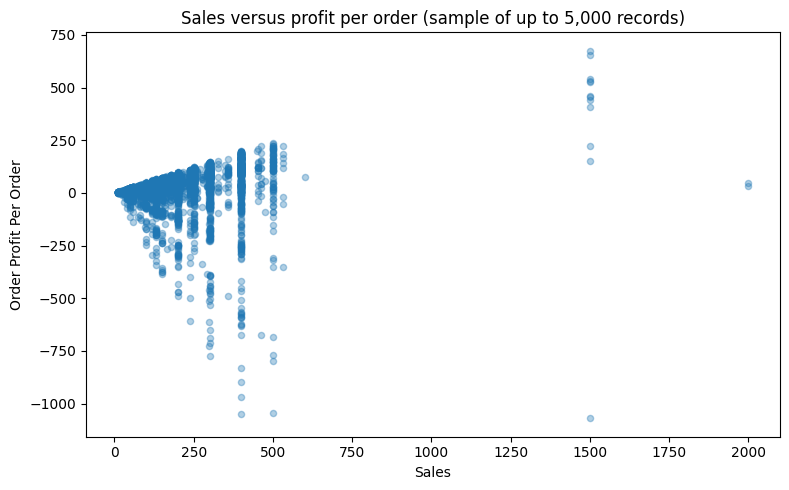


Final check: 180,519 rows, 53 columns, 336,209 missing cells, and 0 exact duplicate rows.


In [10]:
# Correlation shows linear association between numeric measures.
if len(outlier_measures) >= 2:
    correlation = df[outlier_measures].corr()
    display(correlation.round(2))
    fig, ax = plt.subplots(figsize=(10, 7))
    image = ax.imshow(correlation, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
    ax.set_yticks(range(len(correlation.index)), correlation.index)
    fig.colorbar(image, ax=ax, label="Pearson correlation")
    ax.set_title("Correlation between numeric measures")
    fig.tight_layout()
    plt.show()

if {"Market", "Sales"}.issubset(df.columns):
    market_summary = df.groupby("Market", dropna=False).agg(
        record_count=("Sales", "size"),
        mean_sales=("Sales", "mean"),
        median_sales=("Sales", "median"),
        total_sales=("Sales", "sum"),
    )
    if "Order Profit Per Order" in df.columns:
        market_summary["mean_profit_per_order"] = df.groupby("Market", dropna=False)["Order Profit Per Order"].mean()
    print("Sales and profit summary by market:")
    display(market_summary.sort_values("total_sales", ascending=False).round(2))

if {"Shipping Mode", "Late_delivery_risk"}.issubset(df.columns):
    late_risk_by_shipping = df.groupby("Shipping Mode", dropna=False)["Late_delivery_risk"].mean().mul(100)
    print("Late-delivery-risk rate by shipping mode (%):")
    display(late_risk_by_shipping.sort_values(ascending=False).round(2).to_frame("late_risk_percent"))

if {"Shipping Mode", "Delivery Status"}.issubset(df.columns):
    status_by_shipping = pd.crosstab(df["Shipping Mode"], df["Delivery Status"], normalize="index").mul(100)
    print("Delivery status mix within each shipping mode (%):")
    display(status_by_shipping.round(1))

if {"Sales", "Order Profit Per Order"}.issubset(df.columns):
    # Sample points to keep the scatter plot readable and fast.
    scatter_data = df[["Sales", "Order Profit Per Order"]].dropna().sample(
        n=min(5000, df[["Sales", "Order Profit Per Order"]].dropna().shape[0]),
        random_state=42,
    )
    ax = scatter_data.plot.scatter(x="Sales", y="Order Profit Per Order", alpha=0.35, figsize=(8, 5))
    ax.set_title("Sales versus profit per order (sample of up to 5,000 records)")
    plt.tight_layout()
    plt.show()

print(f"\nFinal check: {df.shape[0]:,} rows, {df.shape[1]} columns, {int(missing_mask.sum().sum()):,} missing cells, and {df.duplicated().sum():,} exact duplicate rows.")